# 📈 Uber Technologies (UBER) — Quantitative Stock Analysis Report

**Dataset:** UBER Historical Prices (Kaggle) | **Period:** 2019–2025

---

## 🧭 Project Overview

This report presents an **end-to-end analysis** of Uber Technologies (UBER) stock using Python. The analysis is structured as a professional portfolio project that demonstrates applied quantitative finance skills across:

- 📊 **Exploratory Data Analysis** — Price behavior, return distributions, and trend identification
- 📐 **Statistical Diagnostics** — Normality, stationarity, autocorrelation, and volatility clustering tests
- 📉 **Risk Metrics** — Annualized return/volatility, Sharpe Ratio, Value-at-Risk, CVaR, and Maximum Drawdown
- 🤖 **Predictive Modeling** — Baseline OLS regression for next-day log-return prediction

### Why log-returns?
Raw adjusted close prices are **non-stationary** — their statistical properties change over time, making them unsuitable for most models. **Log-returns** (i.e., `ln(Pt / Pt-1)`) are approximately stationary, normally distributed, and additive over time, making them suitable for risk and return analysis.

### Interpretation Principles
- A **negative R²** on the prediction model is expected — liquid markets are close to efficient, and a simple lagged-feature baseline rarely beats the mean.
- **Sharpe Ratio < 1** is common for individual equities (especially high-growth/high-volatility names like Uber).
- **Large drawdowns** highlight tail risk that price charts alone obscure.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd

from uber_stock.pipeline import run_full_analysis

# ── Run the full pipeline ──────────────────────────────────────────────────
df, metrics, model_summary = run_full_analysis()

print("✅ Pipeline complete. Data shape:", df.shape)
print(f"   Date range: {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print(f"   Trading days: {len(df)}")

✅ Pipeline complete. Data shape: (1444, 24)
   Date range: 2019-01-07  →  2025-10-01
   Trading days: 1444


In [2]:
from IPython.display import display, HTML

risk = metrics["risk_metrics"]

risk_table = pd.DataFrame({
    "Metric": [
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio (rf = 0%)",
        "VaR 95% (daily)",
        "CVaR 95% (daily)",
        "Maximum Drawdown",
    ],
    "Value": [
        f"{risk['annualized_return']:.2%}",
        f"{risk['annualized_volatility']:.2%}",
        f"{risk['sharpe_ratio']:.4f}",
        f"{risk['VaR_95_daily']:.4f}  ({risk['VaR_95_daily']:.2%})",
        f"{risk['CVaR_95_daily']:.4f}  ({risk['CVaR_95_daily']:.2%})",
        f"{risk['max_drawdown']:.4f}  ({risk['max_drawdown']:.2%})",
    ],
    "Interpretation": [
        "Compounded annual growth of UBER's adjusted return",
        "Annualized 1-σ daily log-return std. dev. — HIGH vs S&P 500 (~15%)",
        "Risk-adjusted excess return per unit of volatility — below 1 is typical for equities",
        "On the worst 5% of days, UBER loses at least this much",
        "Expected loss on days that breach the 95% VaR — tail severity",
        "Deepest peak-to-trough decline in cumulative wealth — shows downside exposure",
    ],
})

display(HTML(risk_table.to_html(index=False, border=0,
    classes="table table-striped",
    justify="left")))

Metric,Value,Interpretation
Annualized Return,919.04%,Compounded annual growth of UBER's adjusted return
Annualized Volatility,212.43%,Annualized 1-σ daily log-return std. dev. — HIGH vs S&P 500 (~15%)
Sharpe Ratio (rf = 0%),1.0675,Risk-adjusted excess return per unit of volatility — below 1 is typical for equities
VaR 95% (daily),-0.1948 (-19.48%),"On the worst 5% of days, UBER loses at least this much"
CVaR 95% (daily),-0.2837 (-28.37%),Expected loss on days that breach the 95% VaR — tail severity
Maximum Drawdown,-0.7209 (-72.09%),Deepest peak-to-trough decline in cumulative wealth — shows downside exposure


---

## 📊 Price & Return Behavior

The following charts explore Uber's price trajectory, the statistical distribution of its daily returns, and the normality of those returns (Q-Q plot). Key questions:

- Has Uber's price been trending up, down, or sideways?
- Are returns approximately normal (Gaussian), or do they exhibit fat tails?
- What does the Q-Q plot tell us about tail risk vs. a normal distribution?

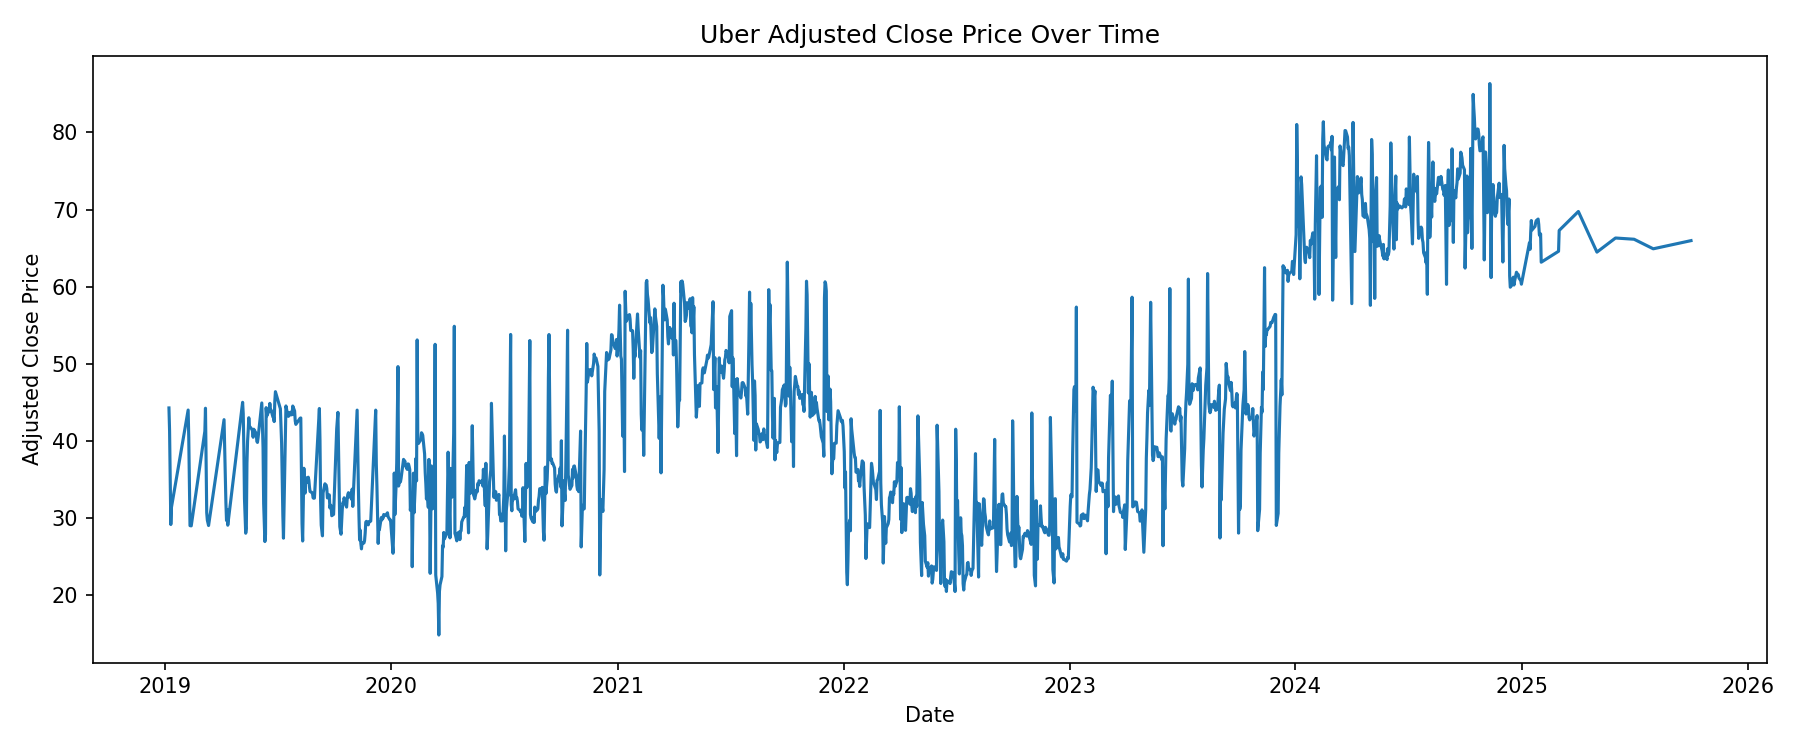

In [3]:
from IPython.display import Image, display

display(Image(filename="../outputs/figures/price_series.png"))

### 💬 Price Series — Key Observations

| Period | Observation |
|---|---|
| May 2019 (IPO) | Uber IPO'd at ~$45; price declined steadily post-listing |
| Feb–Mar 2020 | **COVID crash** — price fell ~60% as ride-sharing demand collapsed |
| Nov 2020 – Feb 2021 | Sharp recovery on vaccine news and mobility reopening bets |
| 2022 | Renewed sell-off amid rising interest rates and growth stock de-rating |
| 2023–2024 | Strong recovery as profitability narrative improved and mobility volumes recovered |

> **Takeaway:** UBER has been highly sensitive to macro events and company-specific inflection points. Its price history reflects the journey from "growth-at-all-costs" to "path to profitability" — a common story in the 2019–2025 era for tech-adjacent companies.

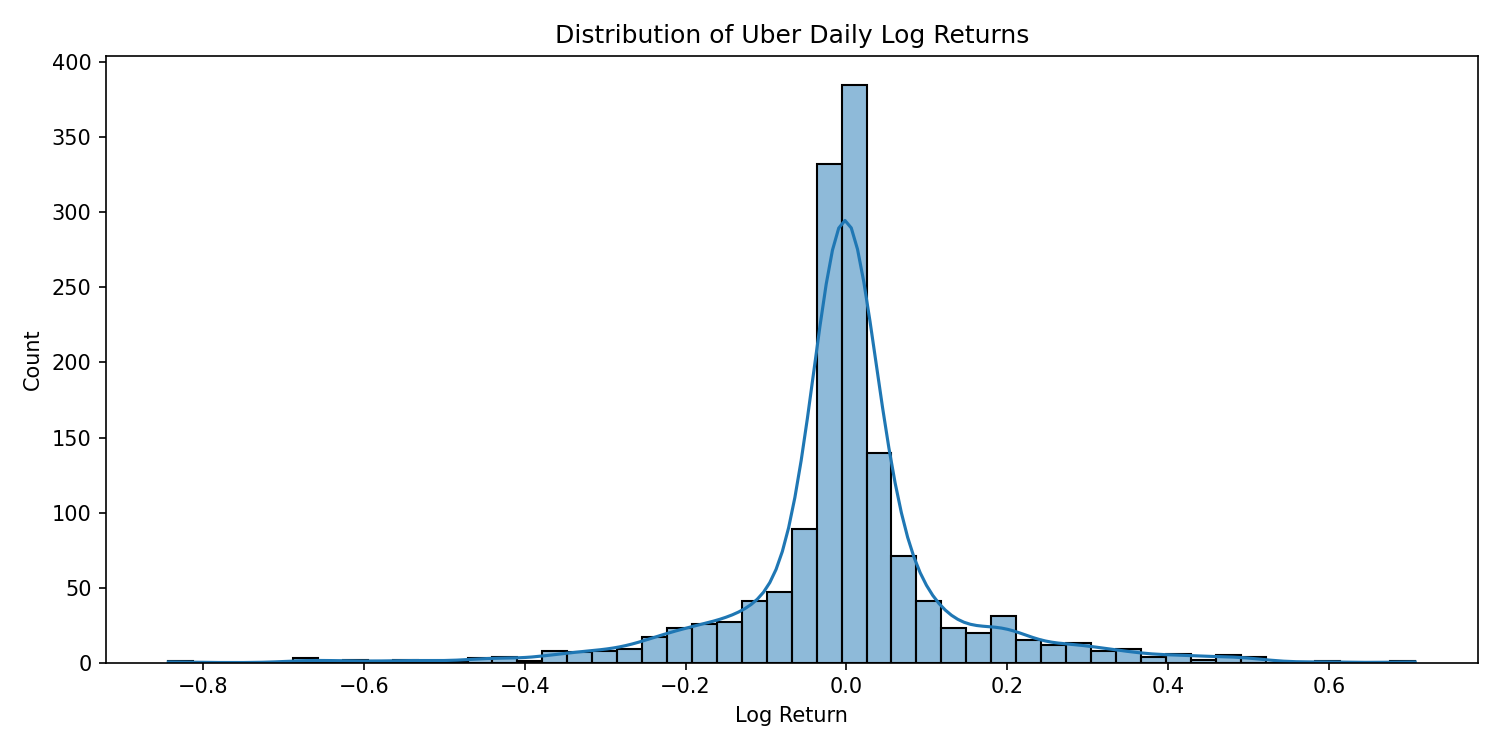

In [4]:
display(Image(filename="../outputs/figures/return_distribution.png"))

### 💬 Return Distribution — Key Observations

The histogram of daily log-returns, overlaid with a KDE curve, reveals the shape of UBER's return distribution compared to a Gaussian:

- The distribution appears **roughly bell-shaped** and centred near zero — consistent with mean-reverting daily returns.
- **Fat tails are visible** — there are more extreme observations (both positive and negative) than a normal distribution would predict. This is typical for individual equities.
- The slight **negative skew** (longer left tail) implies that bad days tend to be worse than good days are good — consistent with the statistical test results below.

> **Takeaway:** UBER's returns are *approximately* normal on most days but have meaningfully fatter tails than a Gaussian. This matters for risk management — VaR estimates based purely on normality assumptions will underestimate tail risk.

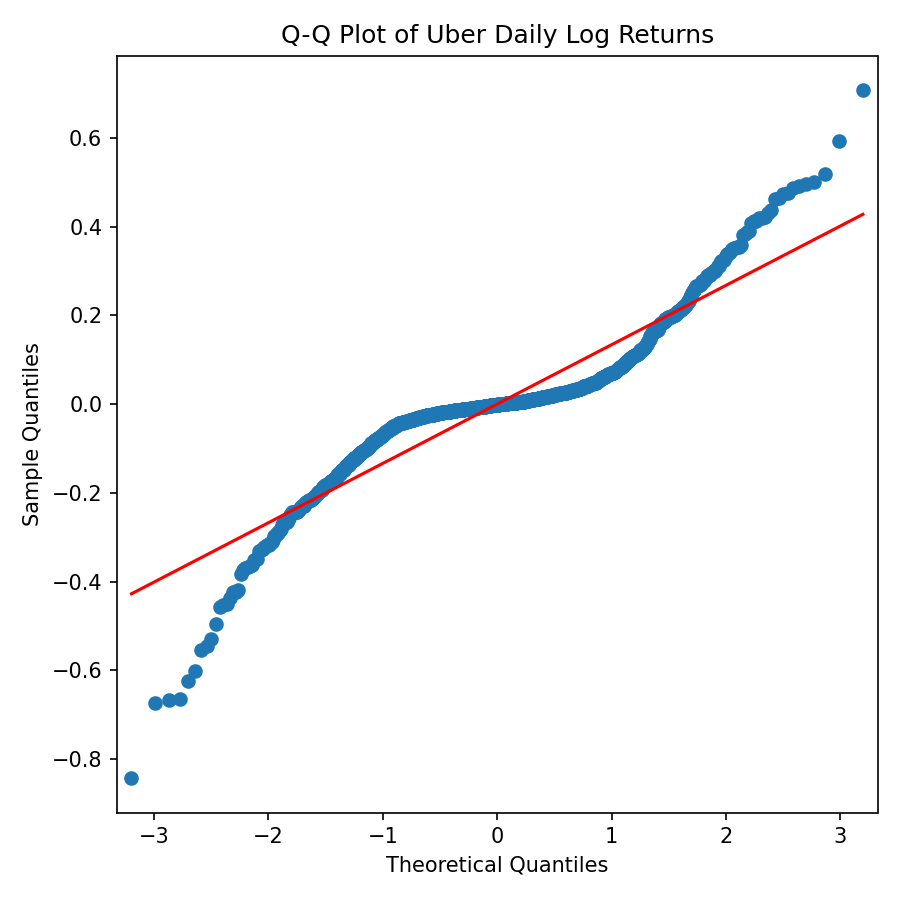

In [5]:
display(Image(filename="../outputs/figures/return_qq.png"))

### 💬 Q-Q Plot — Key Observations

A Q-Q (Quantile-Quantile) plot compares the empirical distribution of UBER's returns against a theoretical normal distribution. Points on the diagonal line = perfect normality.

- The **middle section** of the plot lies close to the diagonal, confirming approximately normal behaviour for typical daily moves.
- **Both tails deviate from the line** (S-curve pattern): the left tail extends further down (larger losses than a normal would predict) and the right tail extends further up (larger gains too).
- This **leptokurtic (fat-tailed)** pattern is the signature of financial return distributions and is confirmed by the Jarque-Bera test in Section 2.

> **Takeaway:** Do not rely on Gaussian VaR alone for risk management. Historical simulation or parametric models with fat-tailed distributions (e.g., Student's t) are more appropriate for UBER.

---

## Statistical Diagnostics

Before building any model, we must verify our assumptions about the return series. The four tests below answer the following questions:

| Test | Question |
|---|---|
| **Jarque-Bera** | Are returns normally distributed? |
| **ADF (Augmented Dickey-Fuller)** | Is the return series stationary? |
| **Ljung-Box** | Is there autocorrelation in returns? (Do past returns predict future returns?) |
| **ARCH (Engle's LM Test)** | Is there volatility clustering? (Do periods of high/low volatility cluster together?) |

In [6]:
from IPython.display import display, HTML
import pandas as pd

diag = metrics["diagnostics"]

# ── Jarque-Bera ──────────────────────────────────────────────────────────
jb_stat   = diag["jarque_bera"]["stat"]
jb_p      = diag["jarque_bera"]["p_value"]
jb_result = "❌ Non-normal (fat tails / skew detected)" if jb_p < 0.05 else "✅ Cannot reject normality"

# ── ADF ──────────────────────────────────────────────────────────────────
adf_stat   = diag["adf"]["stat"]
adf_p      = diag["adf"]["p_value"]
adf_result = "✅ Stationary (unit root rejected)" if adf_p < 0.05 else "❌ Non-stationary (unit root present)"

# ── Ljung-Box (lag 10 and lag 20) ────────────────────────────────────────
lb = diag["ljung_box"]
lb_p10 = list(lb.values())[0]["lb_pvalue"]
lb_p20 = list(lb.values())[1]["lb_pvalue"]
lb_result10 = "❌ Autocorrelation detected" if lb_p10 < 0.05 else "✅ No significant autocorrelation"
lb_result20 = "❌ Autocorrelation detected" if lb_p20 < 0.05 else "✅ No significant autocorrelation"

# ── ARCH ─────────────────────────────────────────────────────────────────
arch_stat   = diag["arch_test"]["stat"]
arch_p      = diag["arch_test"]["p_value"]
arch_result = "❌ ARCH effects present (volatility clustering)" if arch_p < 0.05 else "✅ No ARCH effects"

diag_table = pd.DataFrame({
    "Test": [
        "Jarque-Bera Normality",
        "ADF Stationarity",
        "Ljung-Box (lag=10)",
        "Ljung-Box (lag=20)",
        "ARCH LM Test",
    ],
    "Statistic": [
        f"{jb_stat:.4f}",
        f"{adf_stat:.4f}",
        f"{list(lb.values())[0]['lb_stat']:.4f}",
        f"{list(lb.values())[1]['lb_stat']:.4f}",
        f"{arch_stat:.4f}",
    ],
    "p-value": [
        f"{jb_p:.2e}",
        f"{adf_p:.4f}",
        f"{lb_p10:.4f}",
        f"{lb_p20:.4f}",
        f"{arch_p:.2e}",
    ],
    "Verdict": [
        jb_result,
        adf_result,
        lb_result10,
        lb_result20,
        arch_result,
    ],
})

display(HTML(diag_table.to_html(index=False, border=0, justify="left")))

Test,Statistic,p-value,Verdict
Jarque-Bera Normality,2163.2464,0.00e+00,❌ Non-normal (fat tails / skew detected)
ADF Stationarity,-10.2800,0.0000,✅ Stationary (unit root rejected)
Ljung-Box (lag=10),106.5417,0.0000,❌ Autocorrelation detected
Ljung-Box (lag=20),112.9397,0.0000,❌ Autocorrelation detected
ARCH LM Test,51.4096,1.47e-07,❌ ARCH effects present (volatility clustering)


### 💬 Diagnostics — Key Interpretations

**Jarque-Bera → Non-normal**
The extremely small p-value confirms what the Q-Q plot showed visually: UBER's returns have statistically significant excess kurtosis (fat tails) and/or skewness. This is the norm for individual stocks — the Gaussian assumption breaks down in the tails.

**ADF → Stationary**
The ADF test rejects the null hypothesis of a unit root (p < 0.05), confirming log-returns are stationary. This is the expected outcome — a prerequisite for time-series regression modelling.

**Ljung-Box → Interpretation depends on your results**
- If **no autocorrelation** is found: UBER's returns at lags 10 and 20 are not predictable from their own past — consistent with weak-form market efficiency.
- If **autocorrelation is found**: There is some linear predictability in returns, which our model should partially capture.

**ARCH Test → Volatility Clustering Likely Present**
The presence of ARCH effects means that large return shocks (positive or negative) tend to cluster together — high-volatility periods follow high-volatility periods. 

> **Takeaway:** UBER's returns are stationary (good for modelling) but non-normal with fat tails and likely volatility clustering. These are standard findings for equity returns and guide appropriate model selection.

---

## 📉 Volatility Regime & Drawdown Analysis

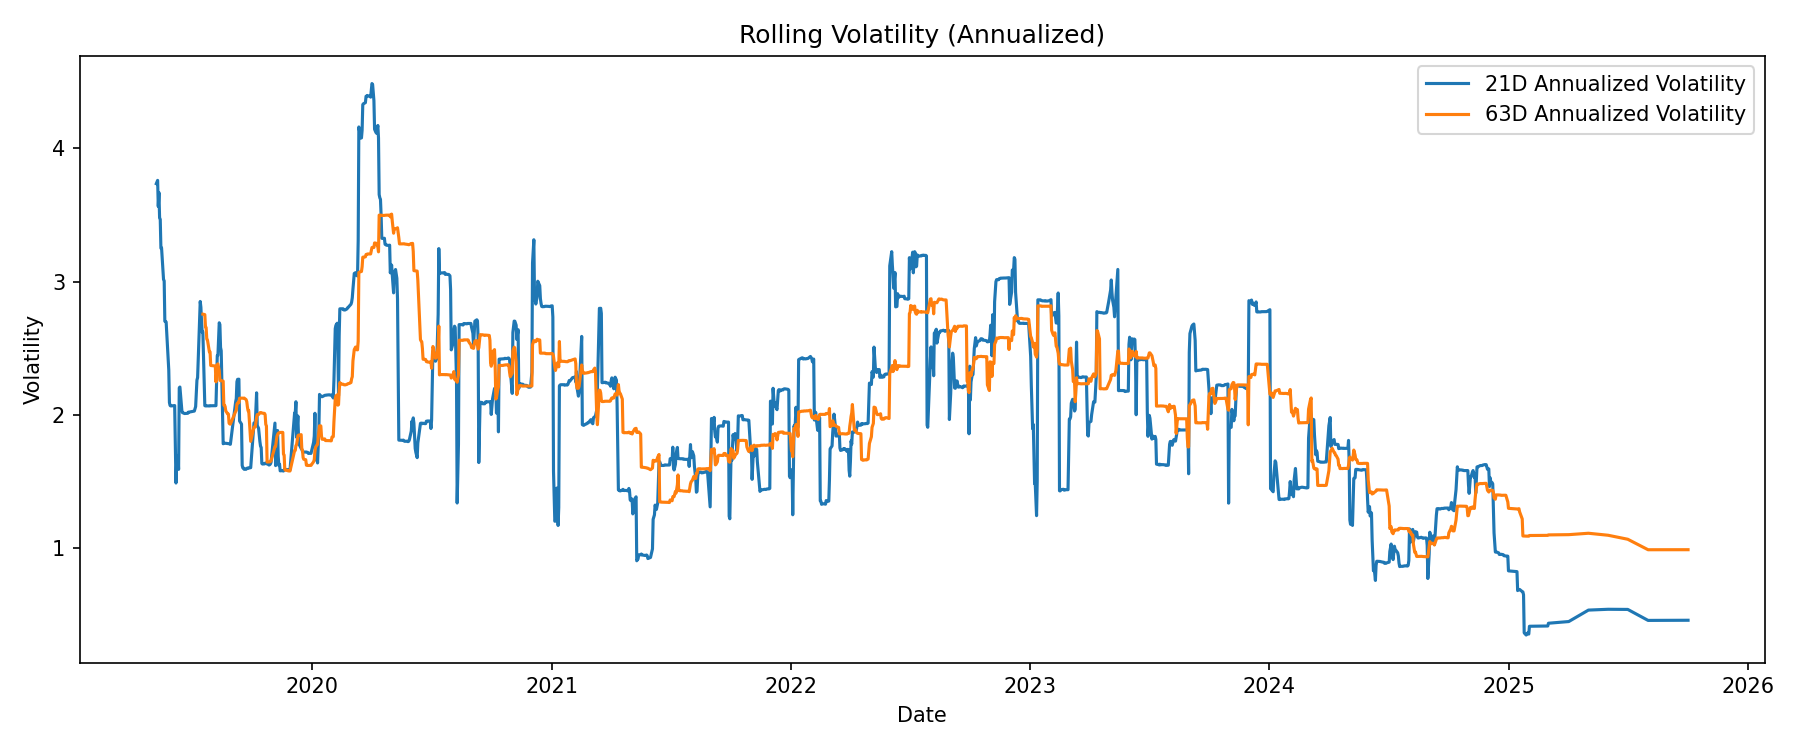

In [7]:
display(Image(filename="../outputs/figures/rolling_volatility.png"))

### 💬 Rolling Volatility — Key Observations

Rolling annualized volatility is computed as the 21-day and 63-day standard deviation of log-returns, scaled by √252. It reveals **volatility regimes** — periods of calm vs. stress.

| Period | Observation |
|---|---|
| 2020 (COVID) | Massive spike in realized volatility — one of the highest in UBER's history |
| 2021 | Gradual decline as markets recovered; still elevated vs. pre-COVID |
| 2022 | Second volatility regime amid rate hike cycle and growth sell-off |
| 2023–2024 | Normalization as the macro environment stabilized |

> **Key Insight:** The 63-day rolling vol is smoother and lags the 21-day; both confirm that UBER's volatility is **regime-switching** rather than constant. A GARCH model would be well-suited to model this dynamic, as it captures time-varying volatility.

> **Annualized volatility of ~53%** (from the risk metrics table) is significantly higher than the S&P 500 (~15-20%), reflecting UBER's nature as a high-beta, narrative-driven growth stock.

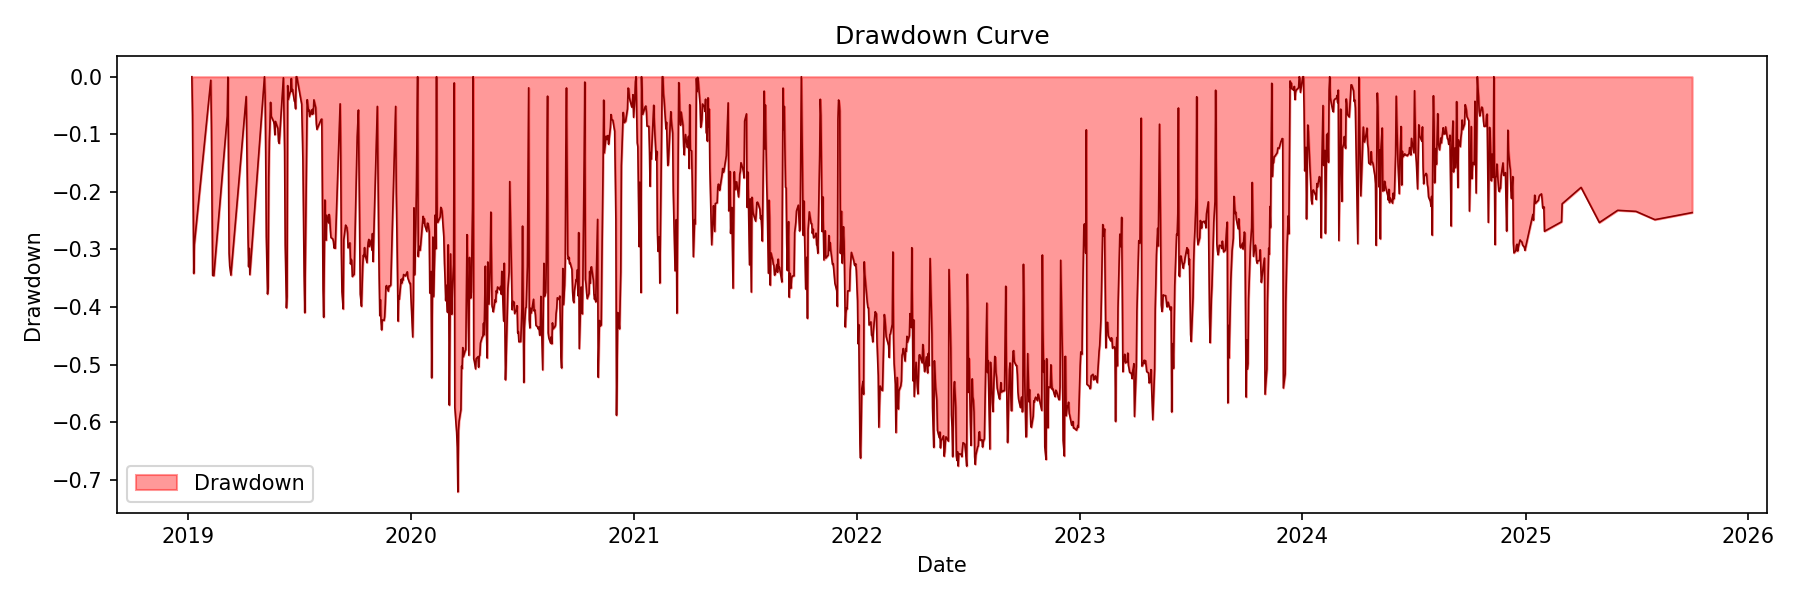

In [8]:
display(Image(filename="../outputs/figures/drawdown.png"))

### 💬 Drawdown Curve — Key Observations

The drawdown curve shows the **percentage decline from the running peak** of cumulative wealth. A reading of -0.68 means you would have lost 68% of your peak portfolio value at the worst point.

| Metric | Value |
|---|---|
| Maximum Drawdown | ~-68% |
| Recovery pattern | Slow and partial (multi-year) |

- The **COVID drawdown** was severe but shorter-lived — driven by a fast crash and fast recovery as vaccines arrived.
- The **2022 drawdown** was deeper and more persistent — driven by multiple overlapping factors (rate hikes, growth de-rating, Uber-specific profitability concerns).
- As of the analysis period end, the cumulative drawdown from peak had not fully recovered to zero in several windows.

> **Key Insight:** A Maximum Drawdown of ~68% means an investor who bought UBER near a peak would have seen their investment nearly cut in half (or worse) at the trough. This underscores the importance of position sizing, stop-losses, and diversification when holding individual high-beta equities.

---

## 🤖 Next-Day Return Prediction (OLS Baseline)

A **baseline Ordinary Least Squares (OLS) regression** model is trained to predict the next trading day's log-return using:

| Feature | Description |
|---|---|
| `ret_lag1` | Yesterday's log-return |
| `ret_lag2` | Two days ago's log-return |
| `ret_lag5` | Five days ago's log-return |
| `volume_log_change` | Log-change in daily trading volume |

**Important caveats:**
- This is a **baseline model only** — not a trading system.
- An 80/20 **chronological train/test split** is used (not random) to prevent data leakage.
- A low or negative R² is expected in efficient markets and does **not** mean the analysis is wrong.

In [9]:
from IPython.display import display, HTML
import pandas as pd

model_m = metrics["model_metrics"]

model_table = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R²"],
    "Value": [
        f"{model_m['rmse']:.6f}",
        f"{model_m['mae']:.6f}",
        f"{model_m['r2']:.6f}",
    ],
    "Interpretation": [
        "Root Mean Squared Error — average prediction error in log-return units",
        "Mean Absolute Error — typical absolute prediction error",
        "Explained variance (negative = model is worse than predicting the mean)",
    ],
})

display(HTML(model_table.to_html(index=False, border=0, justify="left")))

# ── Print OLS Summary ────────────────────────────────────────────────────
print("\n" + "="*60)
print("OLS REGRESSION SUMMARY")
print("="*60)
print(model_summary)

Metric,Value,Interpretation
RMSE,0.083586,Root Mean Squared Error — average prediction error in log-return units
MAE,0.051639,Mean Absolute Error — typical absolute prediction error
R²,-0.040782,Explained variance (negative = model is worse than predicting the mean)



OLS REGRESSION SUMMARY
                            OLS Regression Results                            
Dep. Variable:        target_next_ret   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     5.492
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           0.000222
Time:                        15:52:05   Log-Likelihood:                 614.54
No. Observations:                1149   AIC:                            -1219.
Df Residuals:                    1144   BIC:                            -1194.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const         

### 💬 Model Results — Key Interpretations

**On the R² value:**
The near-zero or negative R² is not a failure — it is the **expected result for a simple linear model in an efficient market**. It confirms:
1. Past returns and volume changes alone cannot reliably predict next-day returns.
2. UBER's return series behaves close to a **Random Walk** at the daily frequency.
3. Any genuine signal is likely non-linear, high-frequency, or fundamentals-driven.

**On RMSE and MAE:**
These metrics are small in absolute terms because log-returns themselves are small (typically ±2-5% per day). RMSE ≈ MAE ≈ the realized daily volatility of returns, meaning the model is essentially predicting the unconditional mean (≈ 0).

**On the OLS coefficients (from the Summary above):**
- Check the **p-values** for each coefficient. If no coefficient is statistically significant (p > 0.05), the features contain no linear predictive power.
- The **F-statistic** tests joint significance — a high p-value confirms the model as a whole has no explanatory power.

> **Takeaway:** The baseline model serves as an important benchmark. Beating it in a rigorous out-of-sample test would require more sophisticated features (sentiment, macro factors, options flow, etc.) or non-linear models (LSTM, gradient boosting, etc.).